# Notebook 02: Model Architecture, Training, & Comparison

**Input**: `zeolite_features_targets.csv` (from Notebook 01)

**Goals**:
1. Train separate single-target models for each of the 3 outputs: (1) CO2 sorption capacity, (2) CO2/N2 selectivity, and (3) regeneration energy.
2. Train joint multi-output/multi-task models that predict all 3 simultaneously.
3. Compare all architectures with a consistent evaluation framework.
4. Identify feature importance for each target.
5. Export the best model(s) for use in Notebook 03.

**Models compared**:
- Linear: Ridge, Lasso, ElasticNet (with auto α tuning)
- Tree-based: Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost
- Kernel: SVR (RBF)
- Multi-output wrappers: MultiOutputRegressor, RegressorChain
- Deep learning: Multi-task neural network (PyTorch)

**Metrics** (rationale in Seciton 2.0):
- R2, RMSE, and MAE evaluated via repeated 5-fold cross-validation.


## 1.0 Environment Setup & Data Loading

In [1]:
import warnings, os, pickle, json, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (KFold, RepeatedKFold, cross_validate, GridSearchCV, train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, make_scorer)
from sklearn.multioutput import MultiOutputRegressor, RegressorChain

# Regression models
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor)
from sklearn.svm import SVR

# Boosting libraries, install if missing
try:
    from xgboost import XGBRegressor
except ImportError:
    print("pip install xgboost")
try:
    from lightgbm import LGBMRegressor
except ImportError:
    print("pip install lightgbm")
try:
    from catboost import CatBoostRegressor
except ImportError:
    print("pip install catboost")

# SHAP for interpretability
try:
    import shap
except ImportError:
    print("pip install shap")

# Optuna for Bayesian hyperparameter tuning
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    print("pip install optuna")

In [2]:
# Load data
INPUT_CSV = "zeolite_features_targets.csv"
df = pd.read_csv(INPUT_CSV, index_col="code")

TARGET_COLS = ["CO2_capacity_mmol_g", "CO2_N2_selectivity", "desorption_energy_kJ_mol"]
NON_FEATURE_COLS = TARGET_COLS + list(df.select_dtypes(include=["object", "str"]).columns)
FEATURE_COLS = [c for c in df.columns if c not in NON_FEATURE_COLS]

X = df[FEATURE_COLS].values
y = df[TARGET_COLS].values
feature_names = FEATURE_COLS
target_names  = TARGET_COLS

print(f"Dataset: {X.shape[0]} samples with {X.shape[1]} features -> {y.shape[1]} targets")
print(f"Excluded non-numeric columns: {[c for c in df.columns if c in NON_FEATURE_COLS and c not in TARGET_COLS]}")
print(f"Features: {feature_names}")

Dataset: 229 samples with 37 features -> 3 targets
Excluded non-numeric columns: ['data_source']
Features: ['accessible_area', 'accessible_area_m2pg', 'occupiable_area', 'occupiable_area_m2pg', 'accessible_volume', 'accessible_volume_pct', 'occupiable_volume_pct', 'specific_occupiable_area', 'lcd', 'pld', 'maxdsi', 'maxdsd_a', 'maxdsd_b', 'maxdsd_c', 'framework_density', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'td10', 'topological_density', 'channel_dim', 'atoms', 'portals', 'cages', 'channels', 'junctions', 'connections', 'vol_accessibility_ratio', 'area_vol_ratio', 'pore_anisotropy', 'confinement_ratio', 'connections_per_atom', 'ab_ratio', 'bc_ratio']


In [3]:
# 80/20 split, stratified by binned capacity (to keep target distribution balanced)
capacity_bins = pd.qcut(df["CO2_capacity_mmol_g"], q=4, labels=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=capacity_bins)
print(f"Train: {X_train.shape[0]}; Test: {X_test.shape[0]}")

Train: 183; Test: 46


## 2.0 Evaluation Metrics & Rationale

A repeated 5-fold cross-validation (3 repeats = 15 fits per model) is used on the training set to get reliable performance estimates with uncertainty bands. The held-out test set is touched only once at the end for final comparison.

For model selection/comparison within each target, R2 is the primary metric. Ties are broken by lower RMSE. All three metrics are reported together so the trade-off between average error (MAE) and worst-case error (RMSE) can be assessed.

| Metric | Measured | Rationale |
|--------|-----------------|---------------|
| **R2** | Fraction of variance explained | Primary ranking metric: Comparable across different target scales |
| **RMSE** | Root-mean-squared error in target units | Penalizes large outlier errors, interpretable in physical units (mmol/g, kJ/mol, etc.) |
| **MAE** | Mean absolute error in target units | Robust to outliers: Useful for zeolites with extreme values |

### 2.1 Evaluation Helper Functions

In [4]:
def evaluate_model(model, X_tr, y_tr, cv, label="model"):
    """Run cross-validation and return a dict of mean ± std for each metric."""
    scoring = {
        "R2":   make_scorer(r2_score),
        "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
        "MAE":  make_scorer(mean_absolute_error, greater_is_better=False),
    }
    results = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring,
                             return_train_score=False, n_jobs=-1)
    return {
        "model": label,
        "R2_mean":   results["test_R2"].mean(),
        "R2_std":    results["test_R2"].std(),
        "RMSE_mean": -results["test_RMSE"].mean(),
        "RMSE_std":  results["test_RMSE"].std(),
        "MAE_mean":  -results["test_MAE"].mean(),
        "MAE_std":   results["test_MAE"].std(),
    }

def test_evaluate(model, X_tr, y_tr, X_te, y_te, label="model"):
    """Fit on full train, score on hold-out test."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        "model": label,
        "R2":   r2_score(y_te, y_pred),
        "RMSE": root_mean_squared_error(y_te, y_pred),
        "MAE":  mean_absolute_error(y_te, y_pred),
    }

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

## 3.0 Single-Target Models

### 3.1 Linear Regression Baseline Models: Ridge, Lasso, ElasticNet

These serve as interpretable baselines. All three use built-in
leave-one-out (LOO) CV to auto-select the regularization strength
α, so no external grid search is needed.

- **Ridge**: L2 penalty - shrinks all coefficients, keeps all features
- **Lasso**: L1 penalty - drives some coefficients to exactly zero (implicit feature selection)
- **ElasticNet**: L1+L2 mix - compromise; `l1_ratio` controls the blend

In [ ]:
# Auto-tuning α via efficient LOO / coordinate-descent CV
# StandardScaler is required for penalized linear models
linear_models = {
    "Ridge": Pipeline([("scaler", StandardScaler()),
                       ("reg", RidgeCV(alphas=np.logspace(-3, 3, 50)))]),
    "Lasso": Pipeline([("scaler", StandardScaler()),
                       ("reg", LassoCV(alphas=np.logspace(-3, 3, 50),
                                       max_iter=10000, cv=5))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()),
                            ("reg", ElasticNetCV(alphas=np.logspace(-3, 3, 50),
                                                 l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                                                 max_iter=10000, cv=5))]),
}

results_per_target = {t: [] for t in target_names}

for tgt_idx, tgt_name in enumerate(target_names):
    y_tr_t = y_train[:, tgt_idx]
    for name, model in linear_models.items():
        res = evaluate_model(model, X_train, y_tr_t, cv, label=name)
        results_per_target[tgt_name].append(res)
    print(f"Linear baseline models done for target {tgt_name}")

# Show results
for tgt_name in target_names:
    print(f"\nBaseline Model Performance for Target {tgt_name}")
    tmp = pd.DataFrame(results_per_target[tgt_name])
    print(tmp.to_string(index=False, float_format="{:.3f}".format))

Linear baseline models done for target CO2_capacity_mmol_g
Linear baseline models done for target CO2_N2_selectivity
Linear baseline models done for target desorption_energy_kJ_mol

Baseline Model Performance for Target CO2_capacity_mmol_g
     model  R2_mean  R2_std  RMSE_mean  RMSE_std  MAE_mean  MAE_std
     Ridge   0.4903  0.1512     0.4153    0.0848    0.2701   0.0538
     Lasso   0.4117  0.2457     0.4384    0.0857    0.2805   0.0464
ElasticNet   0.4119  0.2455     0.4391    0.0947    0.2813   0.0536

Baseline Model Performance for Target CO2_N2_selectivity
     model  R2_mean  R2_std  RMSE_mean  RMSE_std  MAE_mean  MAE_std
     Ridge   0.4533  0.1366    12.6254    3.1351    8.2506   1.7707
     Lasso   0.4582  0.1025    12.5571    2.7881    8.2615   1.5757
ElasticNet   0.4712  0.0807    12.4470    2.7816    8.1799   1.4840

Baseline Model Performance for Target desorption_energy_kJ_mol
     model  R2_mean  R2_std  RMSE_mean  RMSE_std  MAE_mean  MAE_std
     Ridge   0.5061  0.173

### 3.2 Tree-Based Models: Default Hyperparameters

First pass uses reasonable defaults. Section 3.4 will run Optuna hyperparameter optimization on the top performers.

In [6]:
tree_models = {
    "RandomForest":   RandomForestRegressor(n_estimators=300, max_depth=15,
                                            min_samples_leaf=3, n_jobs=-1, random_state=42),
    "ExtraTrees":     ExtraTreesRegressor(n_estimators=300, max_depth=15,
                                          min_samples_leaf=3, n_jobs=-1, random_state=42),
    "GradientBoost":  GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                 learning_rate=0.1, random_state=42),
    "XGBoost":        XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8,
                                   verbosity=0, random_state=42),
    "LightGBM":       LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    verbosity=-1, random_state=42),
    "CatBoost":       CatBoostRegressor(iterations=300, depth=6, learning_rate=0.05,
                                        verbose=0, random_seed=42),
}

for tgt_idx, tgt_name in enumerate(target_names):
    y_tr_t = y_train[:, tgt_idx]
    for name, model in tree_models.items():
        res = evaluate_model(model, X_train, y_tr_t, cv, label=name)
        results_per_target[tgt_name].append(res)
    print(f"Tree models done for target {tgt_name}")

Tree models done for target CO2_capacity_mmol_g
Tree models done for target CO2_N2_selectivity
Tree models done for target desorption_energy_kJ_mol


### 3.3 Support Vector Regression (RBF Kernel)

SVR requires feature scaling. We wrap it in a Pipeline with StandardScaler.

In [7]:
svr_model = {
    "SVR_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale")),
    ])
}

for tgt_idx, tgt_name in enumerate(target_names):
    y_tr_t = y_train[:, tgt_idx]
    for name, model in svr_model.items():
        res = evaluate_model(model, X_train, y_tr_t, cv, label=name)
        results_per_target[tgt_name].append(res)
    print(f"SVR model done for target {tgt_name}")

SVR model done for target CO2_capacity_mmol_g
SVR model done for target CO2_N2_selectivity
SVR model done for target desorption_energy_kJ_mol


### 3.4 Bayesian Hyperparameter Optimization via Optuna Tuning

Tune XGBoost for each target with 80 trials of TPE (Tree-structured Parzen Estimator). The search space covers the main regularization, tree structure, and sampling knobs.

In [ ]:
def xgb_objective(trial, X_tr, y_tr):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "max_depth":        trial.suggest_int("max_depth", 2, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 1e-8, 1.0, log=True),
    }
    model = XGBRegressor(**params, verbosity=0, random_state=42)
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=0)
    scores = cross_validate(model, X_tr, y_tr, cv=inner_cv,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
    return scores["test_score"].mean()  # negative RMSE - Optuna maximizes

best_xgb_models = {}
for tgt_idx, tgt_name in enumerate(target_names):
    y_tr_t = y_train[:, tgt_idx]
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: xgb_objective(trial, X_train, y_tr_t),
                   n_trials=80, show_progress_bar=False)
    best_params = study.best_trial.params
    best_model = XGBRegressor(**best_params, verbosity=0, random_state=42)

    res = evaluate_model(best_model, X_train, y_tr_t, cv, label="XGBoost_tuned")
    results_per_target[tgt_name].append(res)
    best_xgb_models[tgt_name] = best_model
    print(f"  {tgt_name}: best RMSE(CV) = {-study.best_value:.3f}  params = {best_params}")

  CO2_capacity_mmol_g: best RMSE(CV) = 0.2798  params = {'n_estimators': 258, 'max_depth': 7, 'learning_rate': 0.031191328031833637, 'subsample': 0.9414676444652306, 'colsample_bytree': 0.9983335467397257, 'reg_alpha': 0.23682722077155235, 'reg_lambda': 2.661904428601256e-08, 'min_child_weight': 2, 'gamma': 6.741518581739133e-08}
  CO2_N2_selectivity: best RMSE(CV) = 9.1971  params = {'n_estimators': 131, 'max_depth': 9, 'learning_rate': 0.028122951040007244, 'subsample': 0.9164087998653861, 'colsample_bytree': 0.6067261298401658, 'reg_alpha': 1.708311298227096e-06, 'reg_lambda': 0.00014465855531742825, 'min_child_weight': 9, 'gamma': 7.413459594657394e-05}
  desorption_energy_kJ_mol: best RMSE(CV) = 2.1658  params = {'n_estimators': 433, 'max_depth': 9, 'learning_rate': 0.022558863821499995, 'subsample': 0.9576910284103278, 'colsample_bytree': 0.7579634078929252, 'reg_alpha': 0.1041900085003628, 'reg_lambda': 7.6646906465037175, 'min_child_weight': 8, 'gamma': 0.12739741273299188}


### 3.5 Single-Target Model Comparison

Collect all CV results into summary tables and bar charts. The best model per target is highlighted.

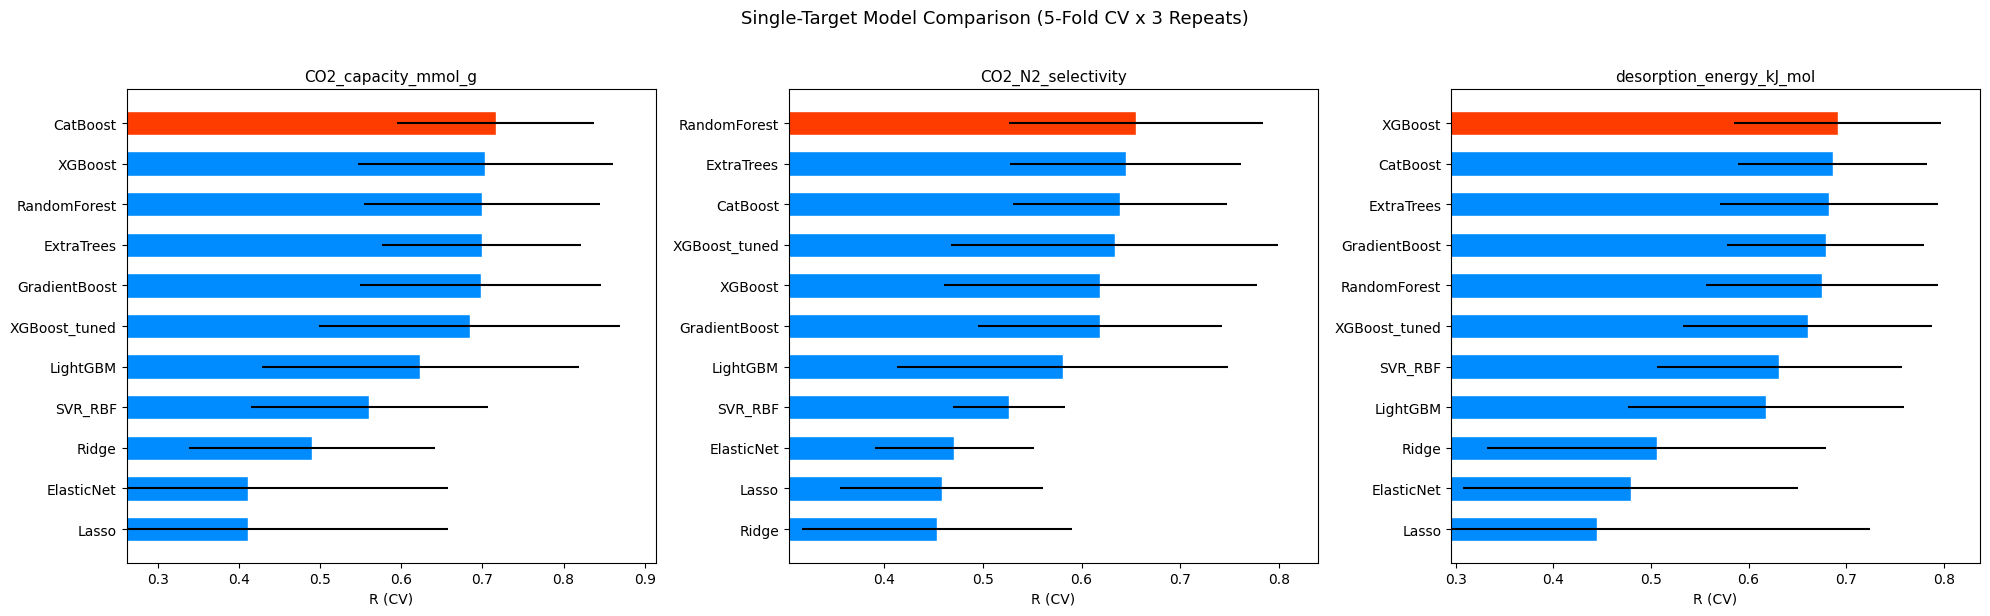

Target: CO2_capacity_mmol_g
        model  R2_mean  R2_std  RMSE_mean  RMSE_std  MAE_mean  MAE_std
     CatBoost   0.7165  0.1210     0.3065    0.0798    0.1961   0.0463
      XGBoost   0.7037  0.1574     0.3074    0.0876    0.1899   0.0504
 RandomForest   0.6995  0.1457     0.3129    0.0858    0.1914   0.0495
   ExtraTrees   0.6993  0.1224     0.3167    0.0823    0.1936   0.0472
GradientBoost   0.6979  0.1483     0.3130    0.0875    0.2021   0.0495
XGBoost_tuned   0.6842  0.1856     0.3143    0.0941    0.1959   0.0509
     LightGBM   0.6237  0.1956     0.3475    0.0828    0.2253   0.0430
      SVR_RBF   0.5607  0.1463     0.3813    0.0799    0.2714   0.0473
        Ridge   0.4903  0.1512     0.4153    0.0848    0.2701   0.0538
   ElasticNet   0.4119  0.2455     0.4391    0.0947    0.2813   0.0536
        Lasso   0.4117  0.2457     0.4384    0.0857    0.2805   0.0464
Target: CO2_N2_selectivity
        model  R2_mean  R2_std  RMSE_mean  RMSE_std  MAE_mean  MAE_std
 RandomForest   0.6553

In [ ]:
best_models_single = {}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, tgt_name in zip(axes, target_names):
    df_res = pd.DataFrame(results_per_target[tgt_name]).sort_values("R2_mean", ascending=False)
    
    # Highlight the best
    best_row = df_res.iloc[0]
    best_models_single[tgt_name] = best_row["model"]
    
    colors = ["#008CFF" if m != best_row["model"] else "#FF3C00" for m in df_res["model"]]
    ax.barh(df_res["model"], df_res["R2_mean"], xerr=df_res["R2_std"],
            color=colors, edgecolor="white", height=0.6)
    ax.set_xlabel("R (CV)")
    ax.set_title(tgt_name, fontsize=11)
    ax.set_xlim(left=max(0, df_res["R2_mean"].min() - 0.15))
    ax.invert_yaxis()

plt.suptitle("Single-Target Model Comparison (5-Fold CV x 3 Repeats)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print full tables
for tgt_name in target_names:
    print(f"Target: {tgt_name}")
    df_res = pd.DataFrame(results_per_target[tgt_name]).sort_values("R2_mean", ascending=False)
    print(df_res.to_string(index=False, float_format="{:.3f}".format))

print(f"\nBest single-target models: {best_models_single}")

## 4.0 Multi-Output Models: Joint Target Prediction

| Strategy | How it works | Strengths |
|----------|-------------|-----------|
| **Native RF** | Single forest, multi-dim leaf values | Captures cross-target correlations implicitly |
| **MultiOutputRegressor(XGB)** | Independent XGB per target, wrapped | Each target gets its own tuned model |
| **RegressorChain(XGB)** | Sequential: capacity -> selectivity -> energy; each model receives prior predictions as extra features | Exploits physical dependency between targets |

In [10]:
# Native multi-output Random Forest
rf_multi = RandomForestRegressor(n_estimators=300, max_depth=15,
                                 min_samples_leaf=3, n_jobs=-1, random_state=42)

# MultiOutputRegressor wrapping tuned XGBoost
# Use the best params from target 0 as representative (could also use per-target params)
xgb_base = XGBRegressor(**best_xgb_models[target_names[0]].get_params())
mor_xgb = MultiOutputRegressor(xgb_base, n_jobs=-1)

# RegressorChain - Order: capacity -> selectivity -> regeneration energy
rc_xgb = RegressorChain(
    base_estimator=XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                verbosity=0, random_state=42),
    order=[0, 1, 2],  # physically motivated ordering
    cv=3,             # cross-validated internal predictions reduce error propagation
)

multi_models = {
    "RF_native_multi": rf_multi,
    "MultiOutput_XGB": mor_xgb,
    "RegressorChain_XGB": rc_xgb,
}

In [11]:
# Evaluate multi-output models per target
multi_results = {t: [] for t in target_names}

scoring_multi = {
    "R2":   make_scorer(r2_score),
    "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
    "MAE":  make_scorer(mean_absolute_error, greater_is_better=False),
}

for name, model in multi_models.items():
    # Fit on full training set once, then score per target on test set
    model.fit(X_train, y_train)
    y_pred_multi = model.predict(X_test)
    
    for tgt_idx, tgt_name in enumerate(target_names):
        r2  = r2_score(y_test[:, tgt_idx], y_pred_multi[:, tgt_idx])
        rmse = root_mean_squared_error(y_test[:, tgt_idx], y_pred_multi[:, tgt_idx])
        mae  = mean_absolute_error(y_test[:, tgt_idx], y_pred_multi[:, tgt_idx])
        multi_results[tgt_name].append({
            "model": name, "R2": r2, "RMSE": rmse, "MAE": mae
        })
    print(f"Test evaluation done for multi-output model: {name}")

# Also evaluate best single-target models on test set for fair comparison
single_test_results = {t: [] for t in target_names}
for tgt_idx, tgt_name in enumerate(target_names):
    y_tr_t = y_train[:, tgt_idx]
    y_te_t = y_test[:, tgt_idx]
    
    # Re-instantiate and train the best single-target model type
    best_label = best_models_single[tgt_name]
    
    # Gather all candidate models
    all_candidates = {**linear_models, **tree_models, **svr_model}
    if best_label == "XGBoost_tuned":
        best_single = best_xgb_models[tgt_name]
    elif best_label in all_candidates:
        best_single = all_candidates[best_label]
    else:
        best_single = RandomForestRegressor(n_estimators=300, random_state=42)
    
    best_single.fit(X_train, y_tr_t)
    y_pred_s = best_single.predict(X_test)
    single_test_results[tgt_name] = {
        "model": f"Best_Single ({best_label})",
        "R2":   r2_score(y_te_t, y_pred_s),
        "RMSE": root_mean_squared_error(y_te_t, y_pred_s),
        "MAE":  mean_absolute_error(y_te_t, y_pred_s),
    }

Test evaluation done for multi-output model: RF_native_multi
Test evaluation done for multi-output model: MultiOutput_XGB
Test evaluation done for multi-output model: RegressorChain_XGB


In [ ]:
# Comparison table: multi-output vs best single-target
print("MULTI-OUTPUT vs SINGLE-TARGET - Test Set Performance")

for tgt_name in target_names:
    print(f"\nPerformance Comparison for Target: {tgt_name}")
    all_rows = multi_results[tgt_name] + [single_test_results[tgt_name]]
    df_comp = pd.DataFrame(all_rows).sort_values("R2", ascending=False)
    print(df_comp.to_string(index=False, float_format="{:.3f}".format))

MULTI-OUTPUT vs SINGLE-TARGET - Test Set Performance

Performance Comparison for Target: CO2_capacity_mmol_g
                 model     R2   RMSE    MAE
       MultiOutput_XGB 0.8297 0.2856 0.1739
       RF_native_multi 0.8212 0.2926 0.2044
Best_Single (CatBoost) 0.8082 0.3031 0.1864
    RegressorChain_XGB 0.7917 0.3159 0.1825

Performance Comparison for Target: CO2_N2_selectivity
                     model     R2   RMSE    MAE
           MultiOutput_XGB 0.8497 8.4756 5.3289
           RF_native_multi 0.8458 8.5860 5.6637
Best_Single (RandomForest) 0.8448 8.6136 5.6312
        RegressorChain_XGB 0.8395 8.7574 5.7747

Performance Comparison for Target: desorption_energy_kJ_mol
                model     R2   RMSE    MAE
      MultiOutput_XGB 0.7612 2.1715 1.4202
      RF_native_multi 0.7610 2.1721 1.5374
Best_Single (XGBoost) 0.7512 2.2165 1.5297
   RegressorChain_XGB 0.6950 2.4538 1.6695


## 5.0 Multi-Task Neural Network (PyTorch)

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class MultiTaskNet(nn.Module):
    def __init__(self, n_features, hidden=(128, 64, 32)):
        super().__init__()
        layers = []
        prev = n_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.15)]
            prev = h
        self.shared = nn.Sequential(*layers)
        # Task-specific heads
        self.head_cap = nn.Sequential(nn.Linear(prev, 16), nn.ReLU(), nn.Linear(16, 1))
        self.head_sel = nn.Sequential(nn.Linear(prev, 16), nn.ReLU(), nn.Linear(16, 1))
        self.head_ene = nn.Sequential(nn.Linear(prev, 16), nn.ReLU(), nn.Linear(16, 1))
    
    def forward(self, x):
        z = self.shared(x)
        return torch.cat([self.head_cap(z), self.head_sel(z), self.head_ene(z)], dim=1)

# Standardize features for NN
scaler_nn = StandardScaler()
X_train_sc = scaler_nn.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler_nn.transform(X_test).astype(np.float32)

# Standardize targets independently (store scalers for inverse transform)
y_scaler = StandardScaler()
y_train_sc = y_scaler.fit_transform(y_train).astype(np.float32)
y_test_sc  = y_scaler.transform(y_test).astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(X_train_sc), torch.from_numpy(y_train_sc))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

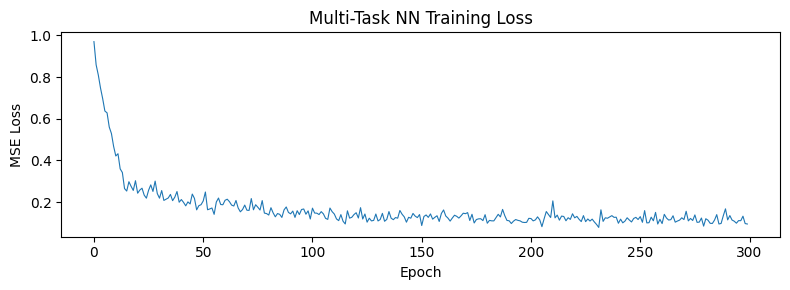

Final training loss: 0.09541


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_nn = MultiTaskNet(X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
criterion = nn.MSELoss()

EPOCHS = 300
losses = []
for epoch in range(EPOCHS):
    model_nn.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        pred = model_nn(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_ds)
    losses.append(epoch_loss)
    scheduler.step(epoch_loss)

plt.figure(figsize=(8, 3))
plt.plot(losses, linewidth=0.8)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.title("Multi-Task NN Training Loss")
plt.tight_layout(); plt.show()
print(f"Final training loss: {losses[-1]:.5f}")

In [15]:
# Evaluate NN on test set (inverse-transform predictions to original scale)
model_nn.eval()
with torch.no_grad():
    y_pred_nn_sc = model_nn(torch.from_numpy(X_test_sc).to(device)).cpu().numpy()
y_pred_nn = y_scaler.inverse_transform(y_pred_nn_sc)

print("\nMulti-Task NN Test Set")
for tgt_idx, tgt_name in enumerate(target_names):
    r2  = r2_score(y_test[:, tgt_idx], y_pred_nn[:, tgt_idx])
    rmse = root_mean_squared_error(y_test[:, tgt_idx], y_pred_nn[:, tgt_idx])
    mae  = mean_absolute_error(y_test[:, tgt_idx], y_pred_nn[:, tgt_idx])
    multi_results[tgt_name].append({"model": "MultiTask_NN", "R2": r2, "RMSE": rmse, "MAE": mae})
    print(f"  {tgt_name}  R2={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")


Multi-Task NN Test Set
  CO2_capacity_mmol_g  R2=0.699  RMSE=0.380  MAE=0.222
  CO2_N2_selectivity  R2=0.730  RMSE=11.355  MAE=7.656
  desorption_energy_kJ_mol  R2=0.705  RMSE=2.412  MAE=1.674


## 6.0 All Model Architecture Comparison

Final side-by-side of every model on the held-out test set.

In [16]:
# Retrain ALL single-target models on full train, evaluate on test
grand_results = {t: [] for t in target_names}

all_single_models = {**linear_models, **tree_models, **svr_model}
all_single_models["XGBoost_tuned"] = None  # placeholder, handled separately

for tgt_idx, tgt_name in enumerate(target_names):
    y_tr_t = y_train[:, tgt_idx]
    y_te_t = y_test[:, tgt_idx]
    
    for name, model in all_single_models.items():
        if name == "XGBoost_tuned":
            model = best_xgb_models[tgt_name]
        from sklearn.base import clone
        m = clone(model)
        m.fit(X_train, y_tr_t)
        yp = m.predict(X_test)
        grand_results[tgt_name].append({
            "model": name, "type": "single",
            "R2":   r2_score(y_te_t, yp),
            "RMSE": root_mean_squared_error(y_te_t, yp),
            "MAE":  mean_absolute_error(y_te_t, yp),
        })
    
    # Add multi-output results already computed
    for row in multi_results[tgt_name]:
        grand_results[tgt_name].append({**row, "type": "multi"})

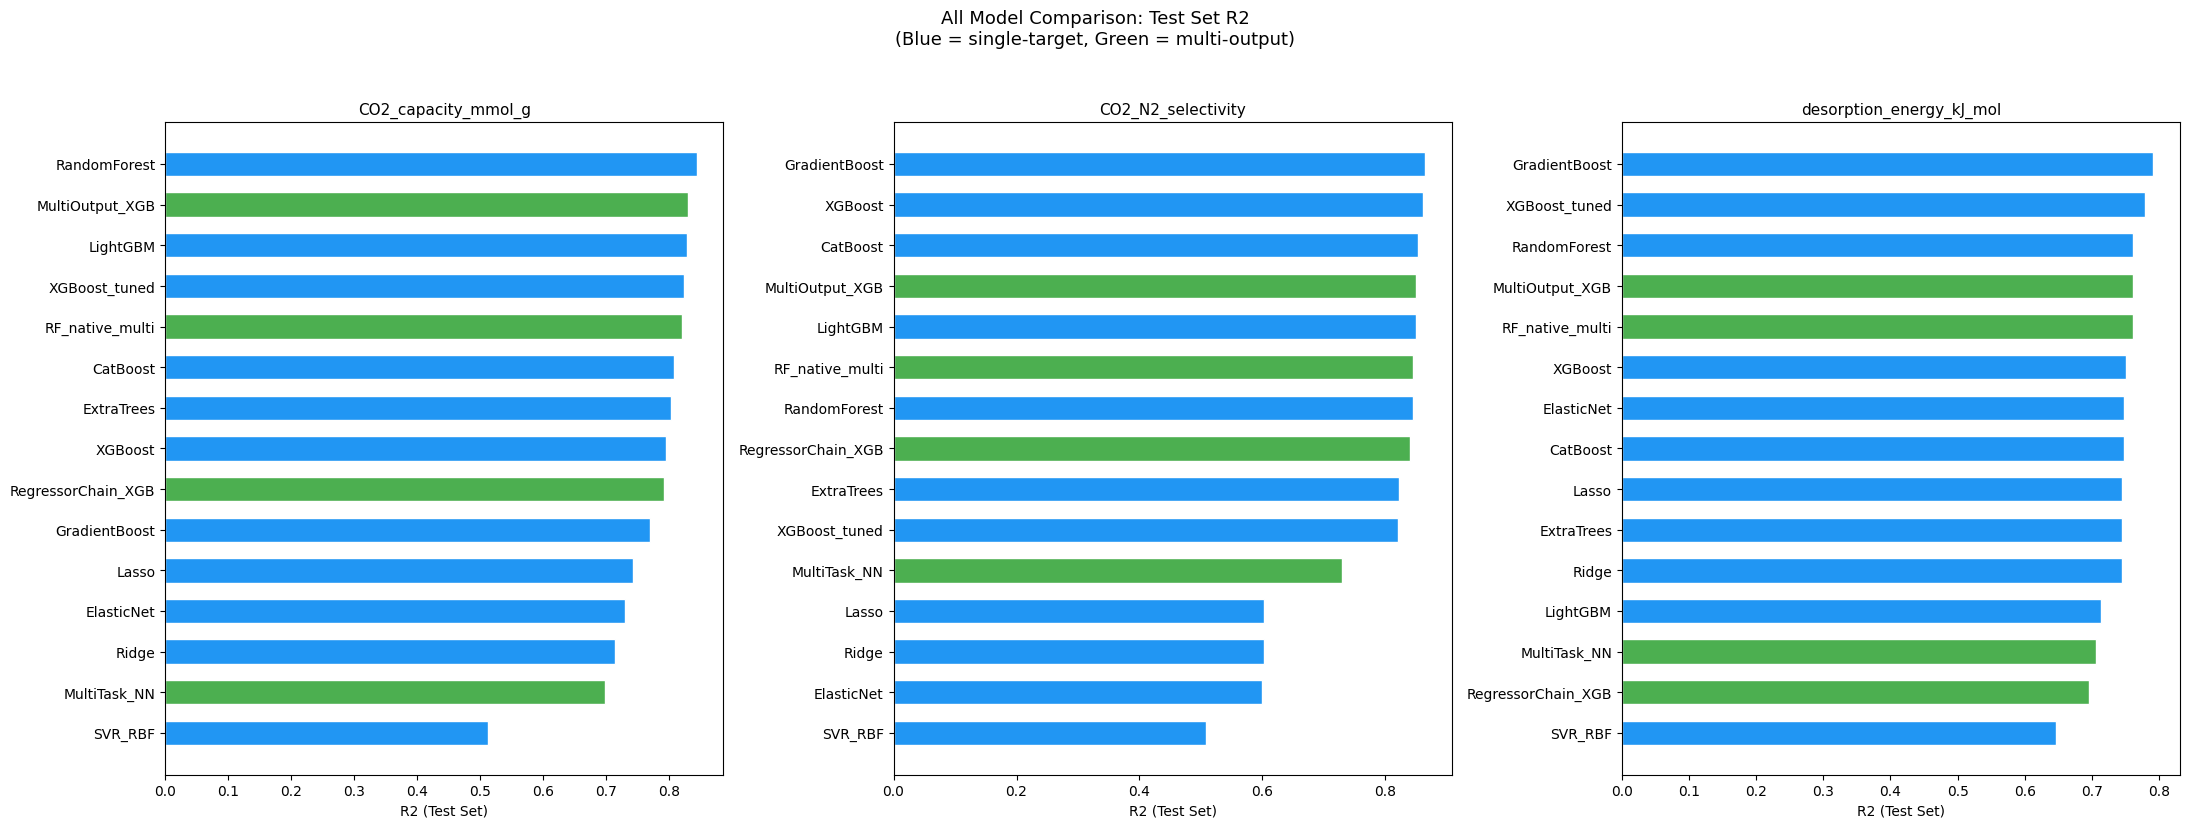

Target: CO2_capacity_mmol_g
             model   type    R2  RMSE   MAE
      RandomForest single 0.844 0.273 0.175
   MultiOutput_XGB  multi 0.830 0.286 0.174
          LightGBM single 0.828 0.287 0.200
     XGBoost_tuned single 0.824 0.290 0.176
   RF_native_multi  multi 0.821 0.293 0.204
          CatBoost single 0.808 0.303 0.186
        ExtraTrees single 0.804 0.306 0.190
           XGBoost single 0.796 0.313 0.184
RegressorChain_XGB  multi 0.792 0.316 0.182
     GradientBoost single 0.770 0.332 0.198
             Lasso single 0.743 0.351 0.241
        ElasticNet single 0.730 0.359 0.248
             Ridge single 0.715 0.370 0.256
      MultiTask_NN  multi 0.699 0.380 0.222
           SVR_RBF single 0.513 0.483 0.278
Target: CO2_N2_selectivity
             model   type    R2   RMSE   MAE
     GradientBoost single 0.865  8.043 5.127
           XGBoost single 0.861  8.144 5.138
          CatBoost single 0.853  8.382 5.520
   MultiOutput_XGB  multi 0.850  8.476 5.329
          LightG

In [17]:
# Display and plot
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for ax, tgt_name in zip(axes, target_names):
    df_g = pd.DataFrame(grand_results[tgt_name]).sort_values("R2", ascending=True)
    colors = ["#4CAF50" if t == "multi" else "#2196F3" for t in df_g["type"]]
    ax.barh(df_g["model"], df_g["R2"], color=colors, edgecolor="white", height=0.6)
    ax.set_xlabel("R2 (Test Set)")
    ax.set_title(tgt_name, fontsize=11)
    ax.axvline(x=0, color="grey", linewidth=0.5)

plt.suptitle("All Model Comparison: Test Set R2\n(Blue = single-target, Green = multi-output)",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

for tgt_name in target_names:
    print(f"Target: {tgt_name}")
    df_g = pd.DataFrame(grand_results[tgt_name]).sort_values("R2", ascending=False)
    print(df_g[["model","type","R2","RMSE","MAE"]].to_string(
        index=False, float_format="{:.3f}".format))

## 7.0 Feature Importance Analysis

### 7.1 SHAP & Permutation

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions. It is run on the best tree model for each target. Permutation importance provides a complementary, model-agnostic check.

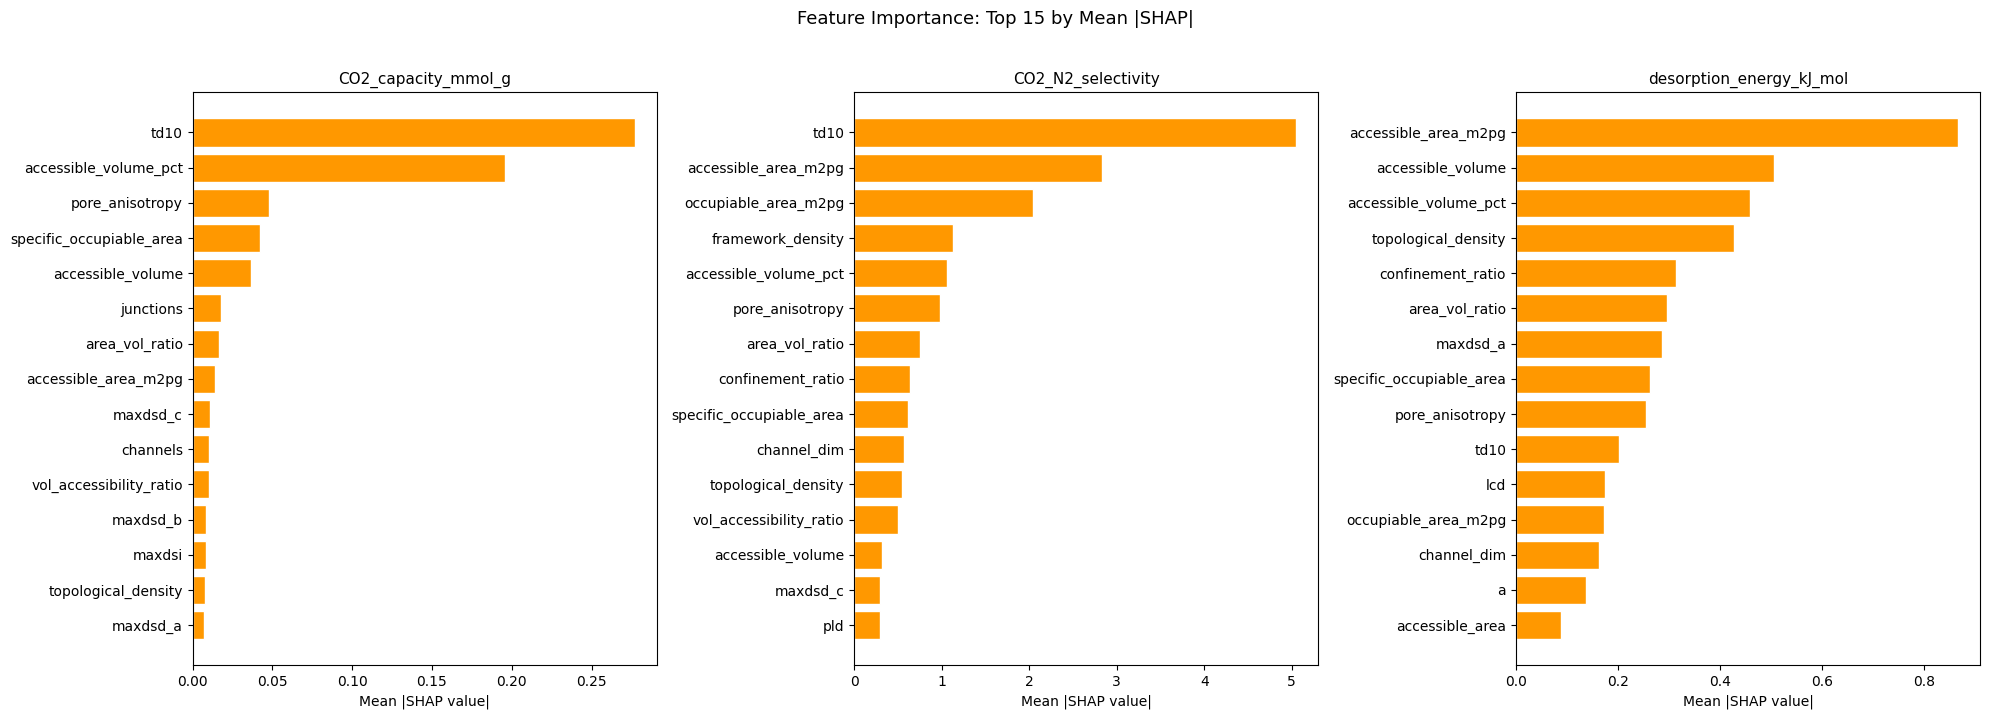

In [18]:
from sklearn.inspection import permutation_importance

fig_shap, axes_shap = plt.subplots(1, 3, figsize=(20, 7))
feature_importance_all = {}

for tgt_idx, tgt_name in enumerate(target_names):
    y_tr_t = y_train[:, tgt_idx]
    
    # Use tuned XGBoost (or RF fallback) for SHAP
    model_for_shap = best_xgb_models.get(tgt_name,
        RandomForestRegressor(n_estimators=300, random_state=42))
    model_for_shap.fit(X_train, y_tr_t)
    
    # SHAP values
    explainer = shap.TreeExplainer(model_for_shap)
    shap_values = explainer.shap_values(X_test)
    
    # Mean |SHAP| as importance
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)
    feature_importance_all[tgt_name] = imp_df
    
    # Bar plot of top 15
    ax = axes_shap[tgt_idx]
    top = imp_df.head(15)
    ax.barh(top["feature"], top["mean_abs_shap"], color="#FF9800", edgecolor="white")
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(tgt_name, fontsize=11)
    ax.invert_yaxis()

plt.suptitle("Feature Importance: Top 15 by Mean |SHAP|", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Permutation importance on test set
print("\nPermutation Importance (top 10 per target):")

for tgt_idx, tgt_name in enumerate(target_names):
    y_tr_t = y_train[:, tgt_idx]
    y_te_t = y_test[:, tgt_idx]
    model_for_pi = best_xgb_models.get(tgt_name,
        RandomForestRegressor(n_estimators=300, random_state=42))
    model_for_pi.fit(X_train, y_tr_t)
    
    pi = permutation_importance(model_for_pi, X_test, y_te_t,
                                n_repeats=15, random_state=42, n_jobs=-1)
    pi_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": pi.importances_mean,
        "importance_std":  pi.importances_std,
    }).sort_values("importance_mean", ascending=False)
    
    print(f"\nTarget: {tgt_name}")
    print(pi_df.head(10).to_string(index=False, float_format="{:.3f}".format))


Permutation Importance (top 10 per target):

Target: CO2_capacity_mmol_g
                 feature  importance_mean  importance_std
                    td10            0.588           0.173
   accessible_volume_pct            0.217           0.052
         pore_anisotropy            0.144           0.050
specific_occupiable_area            0.018           0.024
       accessible_volume            0.013           0.007
                bc_ratio            0.008           0.007
    connections_per_atom            0.006           0.004
     topological_density            0.004           0.003
               junctions            0.004           0.007
    occupiable_area_m2pg            0.002           0.001

Target: CO2_N2_selectivity
                feature  importance_mean  importance_std
                   td10            0.259           0.067
        pore_anisotropy            0.109           0.025
   accessible_area_m2pg            0.073           0.021
   occupiable_area_m2pg         

### 7.2 SHAP Beeswarm Plots: Directional Effects

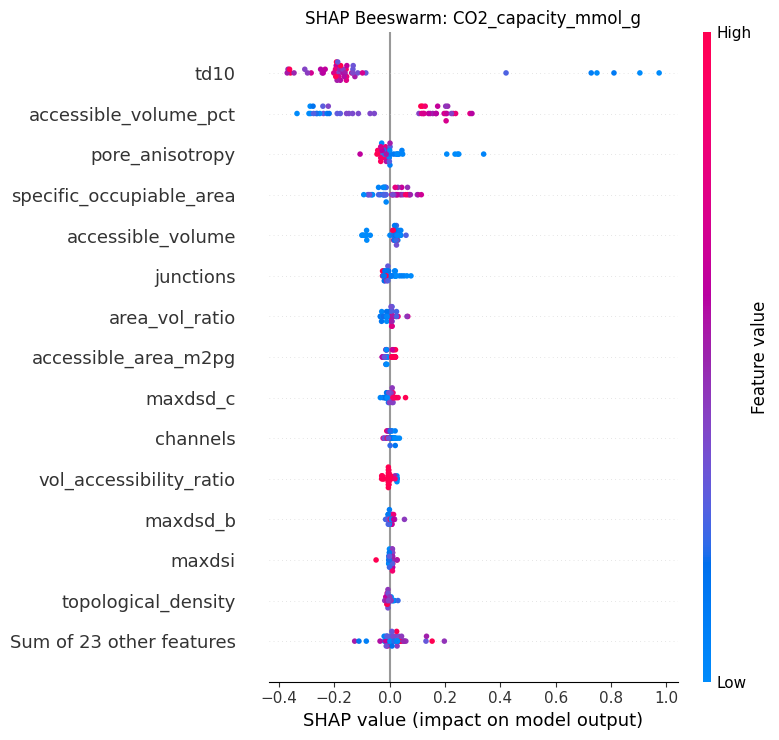

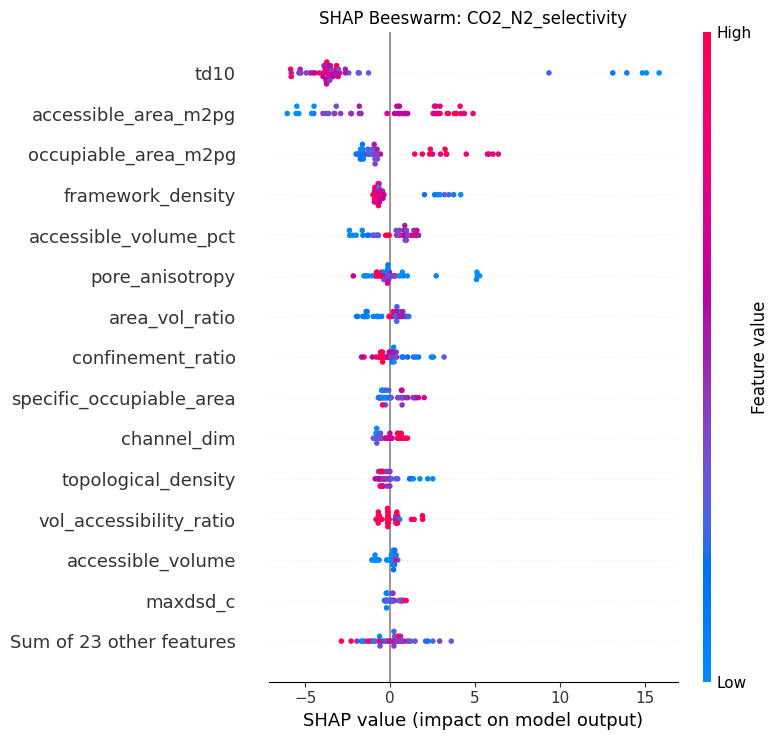

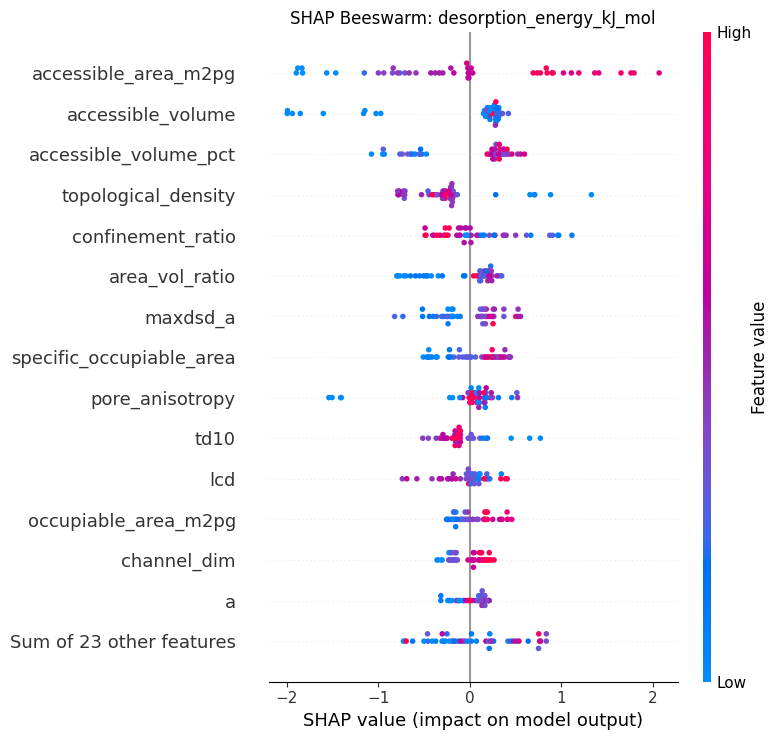

In [24]:
# Beeswarm shows how each feature value (low/high) pushes predictions
for tgt_idx, tgt_name in enumerate(target_names):
    y_tr_t = y_train[:, tgt_idx]
    model_for_shap = best_xgb_models.get(tgt_name,
        RandomForestRegressor(n_estimators=300, random_state=42))
    model_for_shap.fit(X_train, y_tr_t)
    
    explainer = shap.TreeExplainer(model_for_shap)
    sv = explainer(pd.DataFrame(X_test, columns=feature_names))
    
    plt.figure(figsize=(6, 6))
    shap.plots.beeswarm(sv, max_display=15, show=False)
    plt.title(f"SHAP Beeswarm: {tgt_name}", fontsize=12)
    plt.tight_layout()
    plt.show()

## 8.0 Export Best Models & Metadata

Saved artefacts to be used in Notebook 03:
- `best_models.pkl`:     dict of trained model objects
- `model_metadata.json`: best model names, metrics, feature list
- `scaler_nn.pkl`:       feature scaler (if NN is the best for any target)

In [21]:
# Determine overall best model per target from grand results
overall_best = {}
for tgt_name in target_names:
    df_g = pd.DataFrame(grand_results[tgt_name]).sort_values("R2", ascending=False)
    overall_best[tgt_name] = df_g.iloc[0].to_dict()

print("Overall best models:")
for t, info in overall_best.items():
    print(f"- {t}: {info['model']}  R2={info['R2']:.3f}")

Overall best models:
- CO2_capacity_mmol_g: RandomForest  R2=0.844
- CO2_N2_selectivity: GradientBoost  R2=0.865
- desorption_energy_kJ_mol: GradientBoost  R2=0.792


In [22]:
# Retrain best single-target models on FULL training data and save
trained_best = {}
for tgt_idx, tgt_name in enumerate(target_names):
    best_label = overall_best[tgt_name]["model"]
    y_tr_t = y_train[:, tgt_idx]
    
    all_candidates = {**linear_models, **tree_models, **svr_model}
    if best_label == "XGBoost_tuned":
        m = best_xgb_models[tgt_name]
    elif best_label in all_candidates:
        from sklearn.base import clone
        m = clone(all_candidates[best_label])
    elif "RF_native" in best_label:
        m = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
    elif "MultiOutput" in best_label:
        m = mor_xgb  # already multi-output
    elif "Chain" in best_label:
        m = rc_xgb
    else:
        m = RandomForestRegressor(n_estimators=300, random_state=42)
    
    # For multi-output models, train on full y; for single, train on single column
    if "multi" in overall_best[tgt_name].get("type", "single").lower():
        m.fit(X_train, y_train)
    else:
        m.fit(X_train, y_tr_t)
    trained_best[tgt_name] = m

# Also save the best multi-output model (for Notebook 3 joint predictions)
best_multi_label = None
best_multi_r2 = -np.inf
for name, model in multi_models.items():
    avg_r2 = np.mean([
        [r for r in multi_results[t] if r["model"] == name][0]["R2"]
        for t in target_names
        if any(r["model"] == name for r in multi_results[t])
    ])
    if avg_r2 > best_multi_r2:
        best_multi_r2 = avg_r2
        best_multi_label = name

best_multi_model = multi_models[best_multi_label]
best_multi_model.fit(X_train, y_train)
trained_best["_multi_output"] = best_multi_model

# Save
with open("best_models.pkl", "wb") as f:
    pickle.dump(trained_best, f)

metadata = {
    "feature_columns": feature_names,
    "target_columns":  target_names,
    "best_per_target": {t: {k: (str(v) if not isinstance(v, (int, float)) else v)
                            for k, v in info.items()}
                        for t, info in overall_best.items()},
    "best_multi_output": best_multi_label,
    "best_multi_avg_r2": float(best_multi_r2),
}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

with open("scaler_nn.pkl", "wb") as f:
    pickle.dump(scaler_nn, f)

print("Saved: best_models.pkl, model_metadata.json, scaler_nn.pkl")

Saved: best_models.pkl, model_metadata.json, scaler_nn.pkl


---
**Next Step**: Open `03_pareto_ranking.ipynb` to generate Pareto plots
and zeolite rankings using the exported models.